In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-2-2025-kaggle-assignment-3/sample_submission.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-3/train.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-3/test.csv


# Importing required Liberaries

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import string
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import lightgbm as lgb
from sklearn.pipeline import Pipeline, make_pipeline as make_pipeline_p
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score
from matplotlib.patches import Patch
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Loading the Dataset

In [3]:
data_train = pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-3/train.csv')
data_test = pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-3/test.csv')

print(f"Training set dimensions: {data_train.shape}")
print(f"Testing set dimensions: {data_test.shape}")

Training set dimensions: (26500, 10)
Testing set dimensions: (7000, 9)


# Identify data types of different columns

In [4]:
data_train.head()

,id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,0,McDonald's,Fast food restaurant,"9814 International Dr, Orlando, FL 32819, Unit...",28.423814,-81.461242,"5,468",11 months ago,"Very nice staff, good place to get all your fa...",5
1,1,McDonald's,Fast food restaurant,"1100 N US Hwy 377, Roanoke, TX 76262, United S...",33.009318,-97.222925,998,10 months ago,"I think the morning shift are one of, if not t...",5
2,2,McDonald's,Fast food restaurant,"490 8th Ave, New York, NY 10001, United States",40.752529,-73.992876,"3,902",a year ago,Horrible! Avoid this place at night. Unsafe. ...,1
3,3,McDonald's,Fast food restaurant,"111 Madison St, Oak Park, IL 60302, United States",41.879656,-87.777913,"1,454",9 months ago,Employees too busy window licking to get any o...,1
4,4,McDonald's,Fast food restaurant,"5725 W Irlo Bronson Memorial Hwy, Kissimmee, F...",28.333508,-81.513738,"5,566",4 years ago,I'm sorry to give only one star. But during ou...,1


In [5]:
data_test.head()

,id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review
0,0,McDonald's,Fast food restaurant,"8500 US-290, Austin, TX 78724, United States",30.329135,-97.660629,"1,406",2 years ago,The kids love be the Bigfries and The Check in...
1,1,McDonald's,Fast food restaurant,"1415 E State Rd, Fern Park, FL 32730, United S...",28.655350,-81.342692,"1,618",4 years ago,Excellent
2,2,McDonald's,Fast food restaurant,"490 8th Ave, New York, NY 10001, United States",40.752529,-73.992876,"3,902",6 years ago,No change on food standard from other Mac rest...
3,3,McDonald's,Fast food restaurant,"5725 W Irlo Bronson Memorial Hwy, Kissimmee, F...",28.333508,-81.513738,"5,567",a year ago,John was great and super friendly everyone els...
4,4,McDonald's,Fast food restaurant,"72-69 Kissena Blvd, Queens, NY 11367, United S...",40.727401,-73.812460,"2,193",6 years ago,Strange drive thru entrance; quick service. Pa...


In [6]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26500 entries, 0 to 26499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             26500 non-null  int64  
 1   store_name     26500 non-null  object 
 2   category       26500 non-null  object 
 3   store_address  26500 non-null  object 
 4   latitude       25976 non-null  float64
 5   longitude      25976 non-null  float64
 6   rating_count   26500 non-null  object 
 7   review_time    26500 non-null  object 
 8   review         26500 non-null  object 
 9   rating         26500 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 2.0+ MB


#  Descriptive statistics

## For Numerical Columns

In [7]:
data_train.describe()

,id,latitude,longitude,rating
count,26500.000000,25976.000000,25976.000000,26500.000000
mean,13249.500000,34.427152,-90.659226,3.130642
std,7650.035403,5.336112,16.588603,1.615425
min,0.000000,25.790295,-121.995421,1.000000
25%,6624.750000,28.655350,-97.792874,1.000000
50%,13249.500000,33.931261,-81.471414,3.000000
75%,19874.250000,40.727401,-75.399919,5.000000
max,26499.000000,44.981410,-73.459820,5.000000


In [8]:
def map_review_time_to_months(text: str) -> int:
    text = str(text).lower().strip()
    
    # Handle singular expressions starting with "a"
    if text.startswith("a "):
        if "year" in text:
            return 12
        elif any(unit in text for unit in ["month", "week", "day", "hour"]):
            return 1
    
    # Convert years to months
    if "year" in text:
        val = int(re.search(r"\d+", text).group())
        return val * 12
    
    # Months remain as months
    if "month" in text:
        val = int(re.search(r"\d+", text).group())
        return val
    
    # Approximate weeks to months (4 weeks ~ 1 month minimum)
    if "week" in text:
        val = int(re.search(r"\d+", text).group())
        return max(1, val // 4)
    
    # For days and hours, assign minimum 1 month
    if "day" in text or "hour" in text:
        return 1
    
    return pd.NA

In [9]:
data_train["review_time"] = data_train["review_time"].apply(map_review_time_to_months).astype("Int64")
data_test["review_time"] = data_test["review_time"].apply(map_review_time_to_months).astype("Int64")

In [10]:
data_train['rating_count'] = data_train['rating_count'].astype(str).str.replace(',', '').astype(float)
data_test['rating_count'] = data_test['rating_count'].astype(str).str.replace(',', '').astype(float)

In [11]:
# Extracting numerical columns for analysis
num_cols = data_train.select_dtypes(include=['number']).columns

In [12]:
desc_stats = data_train[num_cols].describe().T
print(desc_stats)

                count         mean          std         min        25%  \
id            26500.0      13249.5  7650.035403         0.0    6624.75   
latitude      25976.0    34.427152     5.336112   25.790295   28.65535   
longitude     25976.0   -90.659226    16.588603 -121.995421 -97.792874   
rating_count  26500.0  2589.235585  2528.202311       263.0     1406.0   
review_time   26500.0    34.022453    21.995747         1.0       12.0   
rating        26500.0     3.130642     1.615425         1.0        1.0   

                    50%        75%       max  
id              13249.5   19874.25   26499.0  
latitude      33.931261  40.727401  44.98141  
longitude    -81.471414 -75.399919 -73.45982  
rating_count     1795.0     2810.0   19682.0  
review_time        36.0       48.0     144.0  
rating              3.0        5.0       5.0  


/tmp/ipykernel_13/2919726692.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_13/2919726692.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_13/2919726692.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_13/2919726692.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_13/2919726692.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


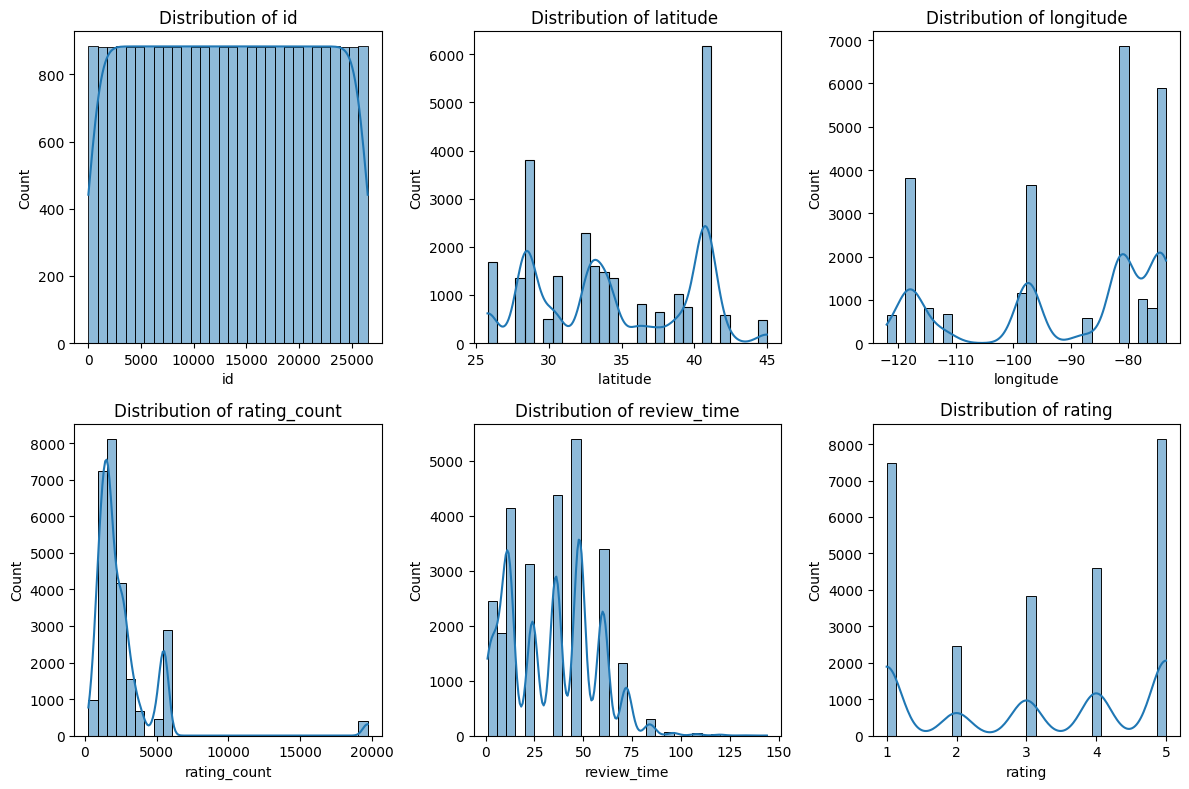

In [13]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data_train[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

## For Categorical Columns

In [14]:
cat_cols = data_train.select_dtypes(include=['object']).columns

In [15]:
data_train[cat_cols].describe().T

,count,unique,top,freq
store_name,26500,2,McDonald's,26445
category,26500,1,Fast food restaurant,26500
store_address,26500,40,"9814 International Dr, Orlando, FL 32819, Unit...",1540
review,26500,18328,Excellent,1706


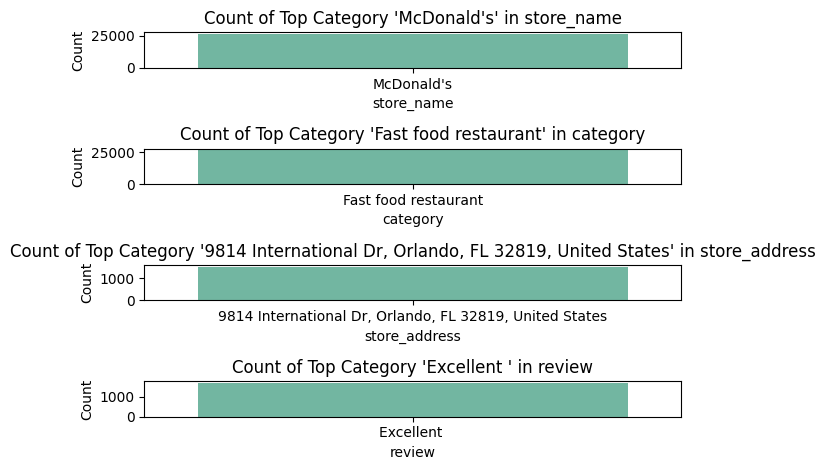

In [16]:

for i, col in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols), 1, i)
    top_category = data_train[col].value_counts().idxmax()
    subset = data_train[data_train[col] == top_category]
    sns.countplot(x=col, data=subset, palette='Set2')
    plt.title(f"Count of Top Category '{top_category}' in {col}")
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Identifying and handling the missing values

In [17]:
print("Missing values in training dataset:\n", data_train.isnull().sum())
print("\nMissing values in testing dataset:\n", data_test.isnull().sum())

Missing values in training dataset:
 id                 0
store_name         0
category           0
store_address      0
latitude         524
longitude        524
rating_count       0
review_time        0
review             0
rating             0
dtype: int64

Missing values in testing dataset:
 id                 0
store_name         0
category           0
store_address      0
latitude         136
longitude        136
rating_count       0
review_time        0
review             0
dtype: int64


In [18]:
# Replace scientific notation values (if any) with NaN - precautionary step
for df in (data_train, data_test):
    df.replace(to_replace=r'^\d+\.\d+[eE][+-]?\d+$', value=np.nan, regex=True, inplace=True)

In [19]:
# Confirm missing values remain the same after replacement
print("Missing values in training dataset after replacement:\n", data_train.isnull().sum())
print("\nMissing values in testing dataset after replacement:\n", data_test.isnull().sum())

Missing values in training dataset after replacement:
 id                 0
store_name         0
category           0
store_address      0
latitude         524
longitude        524
rating_count       0
review_time        0
review             0
rating             0
dtype: int64

Missing values in testing dataset after replacement:
 id                 0
store_name         0
category           0
store_address      0
latitude         136
longitude        136
rating_count       0
review_time        0
review             0
dtype: int64


In [20]:
train_missing = data_train.isnull().sum()
train_missing_cols = train_missing[train_missing > 0]
print("Columns with missing values in training set:\n", train_missing_cols)
test_missing = data_test.isnull().sum()
test_missing_cols = test_missing[test_missing > 0]
print("Columns with missing values in testing set:\n", test_missing_cols)

Columns with missing values in training set:
 latitude     524
longitude    524
dtype: int64
Columns with missing values in testing set:
 latitude     136
longitude    136
dtype: int64


In [21]:
# Columns to impute
impute_cols = ['latitude', 'longitude']

In [22]:
data_train.columns = data_train.columns.str.strip()
data_test.columns = data_test.columns.str.strip()

In [23]:
# Impute missing values in training data using mean strategy
imputer = SimpleImputer(strategy='mean')

imputed_train = data_train[impute_cols].copy()
imputed_train[impute_cols] = imputer.fit_transform(imputed_train[impute_cols])
data_train[impute_cols] = imputed_train

imputed_test = data_test[impute_cols].copy()
imputed_test[impute_cols] = imputer.transform(imputed_test[impute_cols])
data_test[impute_cols] = imputed_test

In [24]:
print("Missing values after imputation in training data:\n", data_train.isnull().sum())
print("\nMissing values after imputation in test data:\n", data_test.isnull().sum() )

Missing values after imputation in training data:
 id               0
store_name       0
category         0
store_address    0
latitude         0
longitude        0
rating_count     0
review_time      0
review           0
rating           0
dtype: int64

Missing values after imputation in test data:
 id               0
store_name       0
category         0
store_address    0
latitude         0
longitude        0
rating_count     0
review_time      0
review           0
dtype: int64


# Identifying and handling duplicates

In [25]:
# Columns to check for duplicates (without trailing spaces)
duplicate_check_cols = [
    'store_name', 'category', 'store_address', 'latitude', 'longitude', 
    'rating_count', 'review_time', 'review', 'rating'
]

# Identify duplicate rows based on these columns
duplicates_mask = data_train.duplicated(subset=duplicate_check_cols)
num_duplicates = duplicates_mask.sum()

print(f"Number of duplicate rows in training data: {num_duplicates}")

# Drop duplicate rows and reset index
data_train = data_train.drop_duplicates(subset=duplicate_check_cols).reset_index(drop=True)

print(f"Training data shape after removing duplicates: {data_train.shape}")

Number of duplicate rows in training data: 3328
Training data shape after removing duplicates: (23172, 10)


# Identifying and handling outliers

In [26]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

data_train.columns = data_train.columns.str.strip()
# Detect outliers in selected numerical columns
for col in ['latitude', 'longitude', 'rating_count', 'review_time']:
    outliers = detect_outliers_iqr(data_train, col)
    print(f"Outliers detected in '{col}': {outliers.shape[0]}")

Outliers detected in 'latitude': 0
Outliers detected in 'longitude': 0
Outliers detected in 'rating_count': 395
Outliers detected in 'review_time': 74


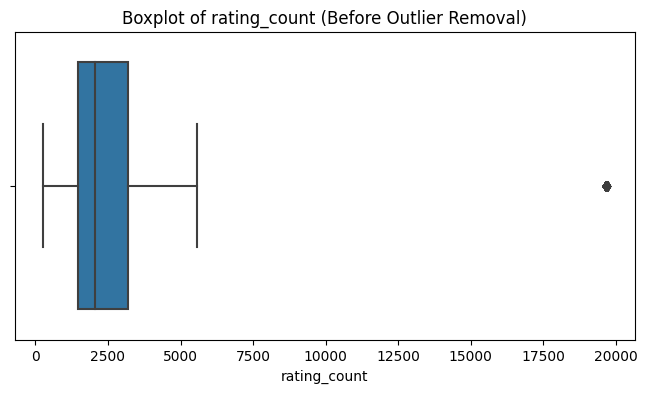

In [27]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data_train['rating_count'])
plt.title("Boxplot of rating_count (Before Outlier Removal)")
plt.show()

In [28]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
# Get numerical columns for outlier removal (with cleaned column names)
numerical_columns = data_train.select_dtypes(include='number').columns

# Remove outliers iteratively from each numerical column
for col in numerical_columns:
    data_train = remove_outliers_iqr(data_train, col)

print(f"Training data shape after outlier removal: {data_train.shape}")

Training data shape after outlier removal: (22703, 10)


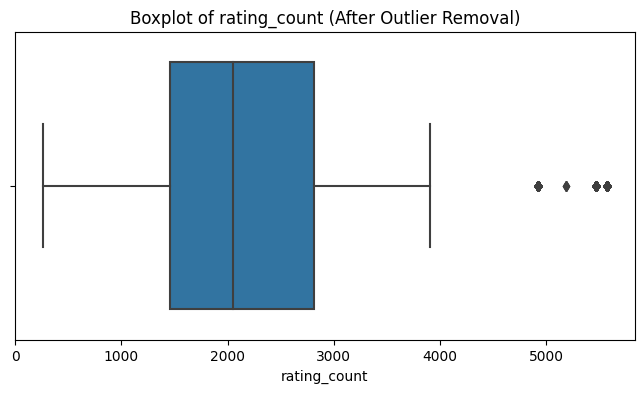

In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data_train['rating_count'])
plt.title("Boxplot of rating_count (After Outlier Removal)")
plt.show()

# Visualizations

## Visualization 1: Scatter plot of store locations

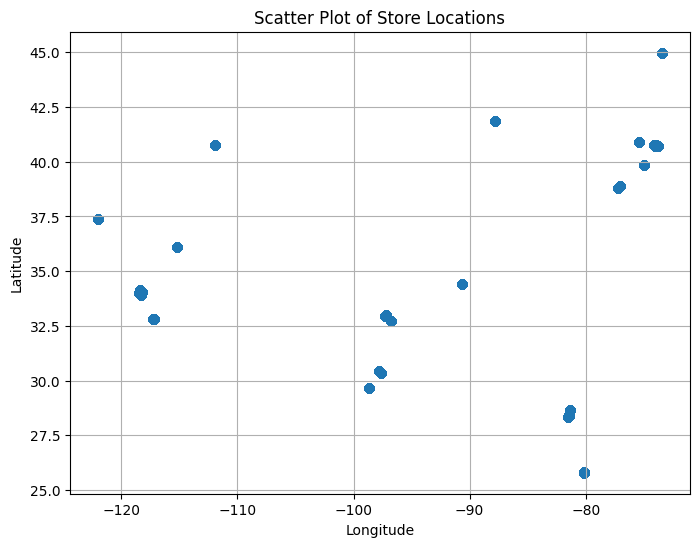

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(data_train['longitude'], data_train['latitude'], alpha=0.6)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Scatter Plot of Store Locations")
plt.grid(True)
plt.show()

## Visualization 2: Distribution of rating_count with KDE

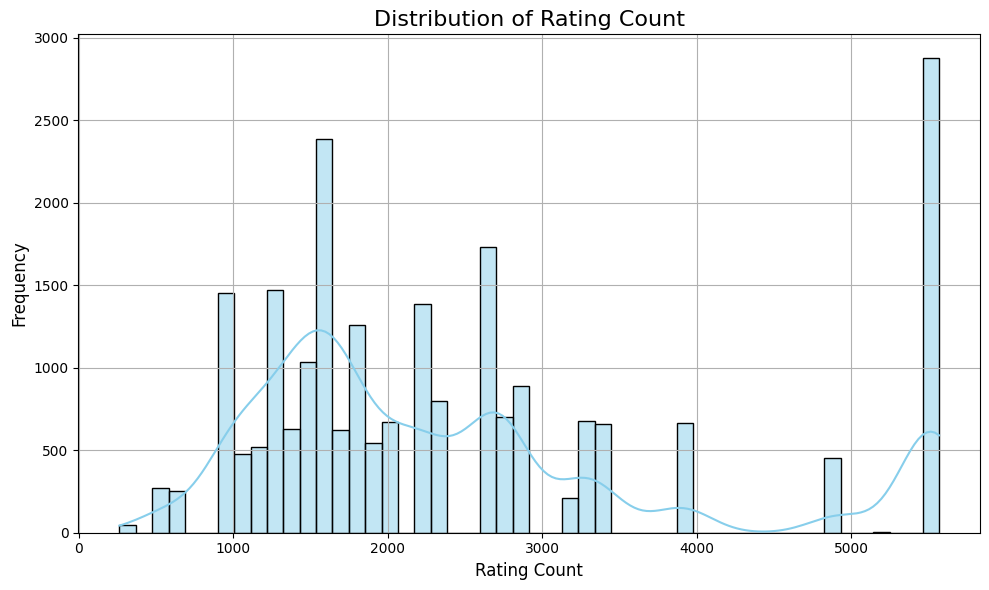

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(data_train['rating_count'], kde=True, bins=50, color='skyblue')
plt.title("Distribution of Rating Count", fontsize=16)
plt.xlabel("Rating Count", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

## Visualization 3: Review Ratings Distribution as a doughnut chart

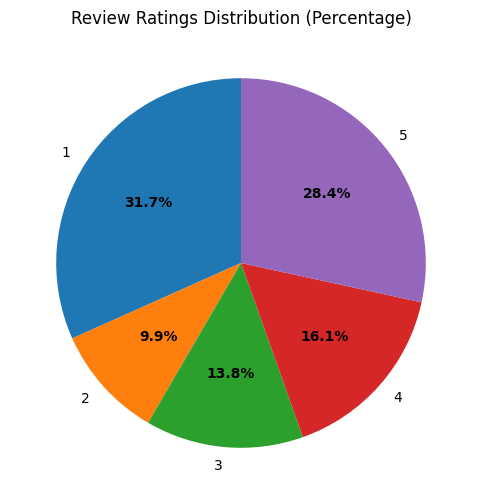

In [32]:
rating_counts = data_train['rating'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',  # Display percentage with one decimal place
    startangle=90
)
plt.setp(autotexts, size=10, weight="bold")
ax.set_title("Review Ratings Distribution (Percentage)")
plt.show()

In [33]:
translator = str.maketrans('', '', string.punctuation + string.digits)

POSITIVE_WORDS = {'good', 'great', 'excellent', 'amazing', 'love', 'best', 'nice', 'friendly', 'fast', 'clean'}
NEGATIVE_WORDS = {'bad', 'terrible', 'awful', 'worst', 'hate', 'rude', 'dirty', 'slow', 'broken', 'horrible', 'avoid'}

def clean_text(text: str) -> str:
    """Lowercase and remove punctuation/digits."""
    return str(text).lower().translate(translator)

def get_sentiment_score(text: str) -> int:
    """Calculate sentiment score: count of positive minus negative words."""
    words = clean_text(text).split()
    pos_count = sum(w in POSITIVE_WORDS for w in words)
    neg_count = sum(w in NEGATIVE_WORDS for w in words)
    return pos_count - neg_count

In [34]:
# Apply cleaning and sentiment calculations
data_train['cleaned_review'] = data_train['review'].apply(clean_text)
data_train['review_length'] = data_train['cleaned_review'].apply(len)
data_train['sentiment_score'] = data_train['cleaned_review'].apply(get_sentiment_score)

valid_reviews = data_train[data_train['review_length'] > 0]

# Correlation between review length and sentiment score
corr = valid_reviews['review_length'].corr(valid_reviews['sentiment_score'])
print(f"Correlation between review length and sentiment score: {corr:.3f}")

Correlation between review length and sentiment score: -0.111


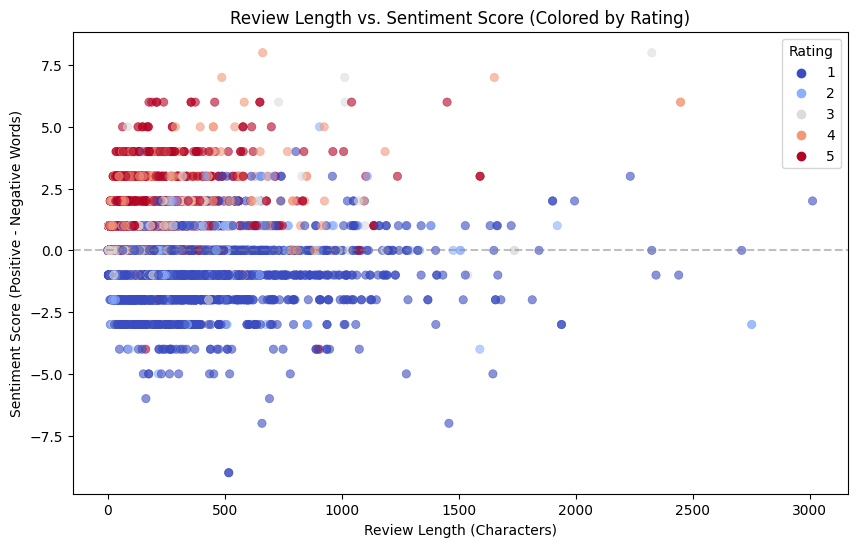

In [35]:
# Scatter plot: Review Length vs Sentiment Score, colored by rating
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=valid_reviews,
    x='review_length',
    y='sentiment_score',
    hue='rating',
    palette='coolwarm',
    alpha=0.6,
    edgecolor=None
)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title("Review Length vs. Sentiment Score (Colored by Rating)")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Sentiment Score (Positive - Negative Words)")
plt.legend(title='Rating', loc='upper right')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


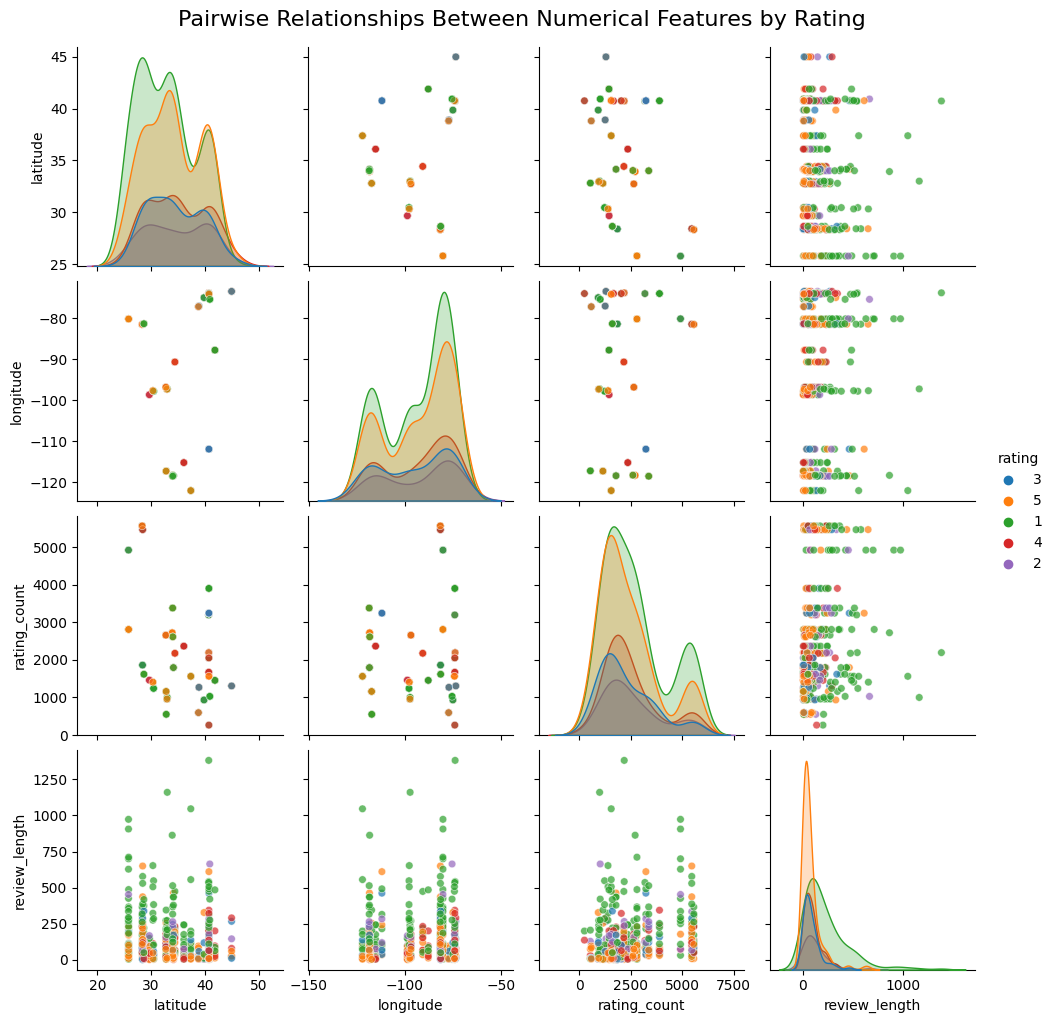

In [36]:
# Pairwise relationships among numerical features by rating
pair_data = data_train[['latitude', 'longitude', 'rating_count', 'review_length', 'rating']].copy()
pair_data['rating'] = pair_data['rating'].astype(str)

pair_sample = pair_data.sample(n=min(500, len(pair_data)), random_state=42)

sns.pairplot(pair_sample, hue='rating', palette='tab10', plot_kws={'alpha': 0.7, 's': 30})
plt.suptitle('Pairwise Relationships Between Numerical Features by Rating', y=1.02, fontsize=16)
plt.show()

# Scaling Numerical features and Encoding Categorical features

In [37]:
# Identify categorical and numerical columns (excluding 'id')
categorical_cols = data_train.select_dtypes(include='object').columns.tolist()
numerical_cols = data_train.select_dtypes(include='number').columns.drop('id').tolist()

print("Categorical Features:", categorical_cols)
print("Numerical Features:", numerical_cols)

Categorical Features: ['store_name', 'category', 'store_address', 'review', 'cleaned_review']
Numerical Features: ['latitude', 'longitude', 'rating_count', 'review_time', 'rating', 'review_length', 'sentiment_score']


In [38]:
# Clean review text function (remove non-alphabetical chars, lowercase)
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower().strip()

In [39]:
# Apply cleaning function to 'review' column in train and test sets
data_train['cleaned_review'] = data_train['review'].apply(clean_text)
data_test['cleaned_review'] = data_test['review'].apply(clean_text)

In [40]:
# Encode 'category' feature using LabelEncoder fitted on combined data
cat_encoder = LabelEncoder()
combined_categories = pd.concat([data_train['category'], data_test['category']], ignore_index=True)
cat_encoder.fit(combined_categories)

data_train['category_encoded'] = cat_encoder.transform(data_train['category'])
data_test['category_encoded'] = cat_encoder.transform(data_test['category'])

In [41]:
# Scale numerical features using StandardScaler
num_cols_to_scale = ['latitude', 'longitude', 'rating_count', 'review_time']
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(data_train[num_cols_to_scale])
X_test_scaled = scaler.transform(data_test[num_cols_to_scale])

train_num_df = pd.DataFrame(X_train_scaled, columns=[f"{col}_scaled" for col in num_cols_to_scale])
test_num_df = pd.DataFrame(X_test_scaled, columns=[f"{col}_scaled" for col in num_cols_to_scale])

In [42]:
# 2. Vectorize text using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
train_tfidf = tfidf.fit_transform(data_train['cleaned_review'])
test_tfidf = tfidf.transform(data_test['cleaned_review'])

In [43]:
# 3. Dimensionality reduction on TF-IDF with Truncated SVD
svd = TruncatedSVD(n_components=100, random_state=42)
train_tfidf_reduced = svd.fit_transform(train_tfidf)
test_tfidf_reduced = svd.transform(test_tfidf)

train_tfidf_df = pd.DataFrame(train_tfidf_reduced, columns=[f"svd_emb_{i}" for i in range(100)])
test_tfidf_df = pd.DataFrame(test_tfidf_reduced, columns=[f"svd_emb_{i}" for i in range(100)])

In [44]:
# Convert reduced features to DataFrame
train_tfidf_df = pd.DataFrame(train_tfidf_reduced, columns=[f"svd_emb_{i}" for i in range(100)])
test_tfidf_df = pd.DataFrame(test_tfidf_reduced, columns=[f"svd_emb_{i}" for i in range(100)])

In [45]:
# Combine scaled numerical features, encoded category, and review embeddings into final datasets
X_train_final = pd.concat([
    train_num_df.reset_index(drop=True),
    data_train[['category_encoded']].reset_index(drop=True),
    train_tfidf_df.reset_index(drop=True)
], axis=1)

y_train = data_train['rating'].astype(int)

X_test_final = pd.concat([
    test_num_df.reset_index(drop=True),
    data_test[['category_encoded']].reset_index(drop=True),
    test_tfidf_df.reset_index(drop=True)
], axis=1)

# Print shapes and check for missing values
print("Final training feature set shape:", X_train_final.shape)
print("Final test feature set shape:", X_test_final.shape)
print("Missing values in training features:", X_train_final.isnull().sum().sum())
print("Missing values in test features:", X_test_final.isnull().sum().sum())

Final training feature set shape: (22703, 105)
Final test feature set shape: (7000, 105)
Missing values in training features: 0
Missing values in test features: 0


# Model Building

In [46]:
# Split data into training and validation sets with stratification
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [47]:
# creating a modeling pipeline
def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('estimator', model)
    ])

In [48]:
# Defining models to train
models = {
    'Logistic Regression': make_pipeline(LogisticRegression(max_iter=1000, random_state=42)),
    'Random Forest': make_pipeline(RandomForestClassifier(n_estimators=100, random_state=42)),
    'Gradient Boosting': make_pipeline(HistGradientBoostingClassifier(random_state=42)),
    'AdaBoost': make_pipeline(AdaBoostClassifier(random_state=42)),
    'Extra Trees': make_pipeline(ExtraTreesClassifier(n_estimators=100, random_state=42)),
    'K-Nearest Neighbors': make_pipeline(KNeighborsClassifier()),
    'Gaussian Naive Bayes': make_pipeline(GaussianNB()),
    'LightGBM': make_pipeline(lgb.LGBMClassifier(random_state=42, verbose=-1)),
}

In [49]:
model_performance = {}

# Train each model and evaluate accuracy on validation data
for name, model in models.items():
    print(f"Training {name}...")
    try:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        model_performance[name] = accuracy
        print(f"{name} Accuracy: {accuracy:.4f}")
    except Exception as e:
        print(f"Failed to train {name}: {e}")

Training Logistic Regression...
Logistic Regression Accuracy: 0.5807
Training Random Forest...
Random Forest Accuracy: 0.6294
Training Gradient Boosting...
Gradient Boosting Accuracy: 0.6228
Training AdaBoost...
AdaBoost Accuracy: 0.5345
Training Extra Trees...
Extra Trees Accuracy: 0.6237
Training K-Nearest Neighbors...
K-Nearest Neighbors Accuracy: 0.4873
Training Gaussian Naive Bayes...
Gaussian Naive Bayes Accuracy: 0.4959
Training LightGBM...
LightGBM Accuracy: 0.6230


In [50]:
# Identify the best performing model and its accuracy
best_model_name = max(model_performance, key=model_performance.get)
best_accuracy = model_performance[best_model_name]

print(f"\nBest Performing Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")


Best Performing Model: Random Forest with Accuracy: 0.6294


# Hyperparameter Tuning on any 3 of the models

In [51]:
# Define a reusable pipeline builder
def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('estimator', model)
    ])


In [52]:
# Hyperparameter tuning for LightGBM using RandomizedSearchCV
print("Tuning LightGBM...")
lgbm_pipe = make_pipeline_p(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    lgb.LGBMClassifier(random_state=42, verbose=-1)
)

Tuning LightGBM...


In [53]:
lgbm_params = {
    'lgbmclassifier__n_estimators': [100, 200],
    'lgbmclassifier__learning_rate': [0.05, 0.1],
    'lgbmclassifier__num_leaves': [31, 63],
    'lgbmclassifier__max_depth': [-1, 8]
}

lgbm_random = RandomizedSearchCV(
    estimator=lgbm_pipe,
    param_distributions=lgbm_params,
    n_iter=4,
    cv=2,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
lgbm_random.fit(X_tr, y_tr)

print("Best LightGBM Parameters:", lgbm_random.best_params_)
print("Best LightGBM Accuracy:", lgbm_random.best_score_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best LightGBM Parameters: {'lgbmclassifier__num_leaves': 63, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__max_depth': -1, 'lgbmclassifier__learning_rate': 0.05}
Best LightGBM Accuracy: 0.5958594868406564


In [54]:
# Hyperparameter tuning for ExtraTrees using GridSearchCV
print("Tuning ExtraTrees...")
et_params = {
    'estimator__n_estimators': [100, 150],
    'estimator__max_depth': [None, 15],
    'estimator__min_samples_split': [2, 5]
}
et_grid = GridSearchCV(
    make_pipeline(ExtraTreesClassifier(random_state=42)),
    et_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
et_grid.fit(X_tr, y_tr)
et_best = et_grid.best_estimator_
print("Best ExtraTrees Parameters:", et_grid.best_params_)


Tuning ExtraTrees...
Best ExtraTrees Parameters: {'estimator__max_depth': None, 'estimator__min_samples_split': 5, 'estimator__n_estimators': 150}


In [55]:
# Hyperparameter tuning for RandomForest using GridSearchCV
print("Tuning RandomForest...")
rf_params = {
    'estimator__n_estimators': [100, 150],
    'estimator__max_depth': [None, 12],
    'estimator__min_samples_split': [2, 4]
}
rf_grid = GridSearchCV(
    make_pipeline(RandomForestClassifier(random_state=42)),
    rf_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_tr, y_tr)
rf_best = rf_grid.best_estimator_
print("Best RandomForest Parameters:", rf_grid.best_params_)

Tuning RandomForest...
Best RandomForest Parameters: {'estimator__max_depth': None, 'estimator__min_samples_split': 4, 'estimator__n_estimators': 150}


In [56]:
# Evaluate tuned models on validation set
models_tuned = {
    'LGBM_Tuned': lgbm_random,
    'ExtraTrees_Tuned': et_best,
    'RandomForest_Tuned': rf_best
}

val_accuracies = {}

for name, model in models_tuned.items():
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    val_accuracies[name] = acc
    print(f"{name} Validation Accuracy: {acc:.4f}")


LGBM_Tuned Validation Accuracy: 0.6303
ExtraTrees_Tuned Validation Accuracy: 0.6327
RandomForest_Tuned Validation Accuracy: 0.6320


In [57]:
# Ensemble weights based on validation accuracies
weights = [
    val_accuracies['LGBM_Tuned'],
    val_accuracies['ExtraTrees_Tuned'],
    val_accuracies['RandomForest_Tuned']
]
print(f"Ensemble Weights (by validation accuracy): {weights}")

Ensemble Weights (by validation accuracy): [0.6302576524994494, 0.6326800264258974, 0.6320193789914116]


In [58]:
# Select best model for final prediction
best_model = lgbm_random

# Predict on test set
final_predictions = best_model.predict(X_test_final)

In [59]:
# Prepare submission DataFrame and save as CSV
submission = pd.DataFrame({
    'id': data_test['id'],
    'rating': final_predictions.astype(int)
})

submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created successfully.")

Submission file 'submission.csv' created successfully.


# Comparison of model performances

In [60]:
# Create DataFrame for base model performances
results_base = pd.DataFrame(list(model_performance.items()), columns=['Model', 'Accuracy'])
results_base['Type'] = 'Base'

# Create DataFrame for tuned model performances
results_tuned = pd.DataFrame(list(val_accuracies.items()), columns=['Model', 'Accuracy'])
results_tuned['Type'] = 'Tuned'

# Combine base and tuned results
results_df = pd.concat([results_base, results_tuned], ignore_index=True)

# Sort combined results by accuracy descending
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

# Identify the best performing model overall
best_model = results_df.loc[results_df['Accuracy'].idxmax()]

print("Detailed Performance Table (Base + Tuned):")
print(results_df.to_string(index=True))

Detailed Performance Table (Base + Tuned):
                   Model  Accuracy   Type
0       ExtraTrees_Tuned  0.632680  Tuned
1     RandomForest_Tuned  0.632019  Tuned
2             LGBM_Tuned  0.630258  Tuned
3          Random Forest  0.629377   Base
4            Extra Trees  0.623651   Base
5               LightGBM  0.622991   Base
6      Gradient Boosting  0.622770   Base
7    Logistic Regression  0.580709   Base
8               AdaBoost  0.534464   Base
9   Gaussian Naive Bayes  0.495926   Base
10   K-Nearest Neighbors  0.487338   Base


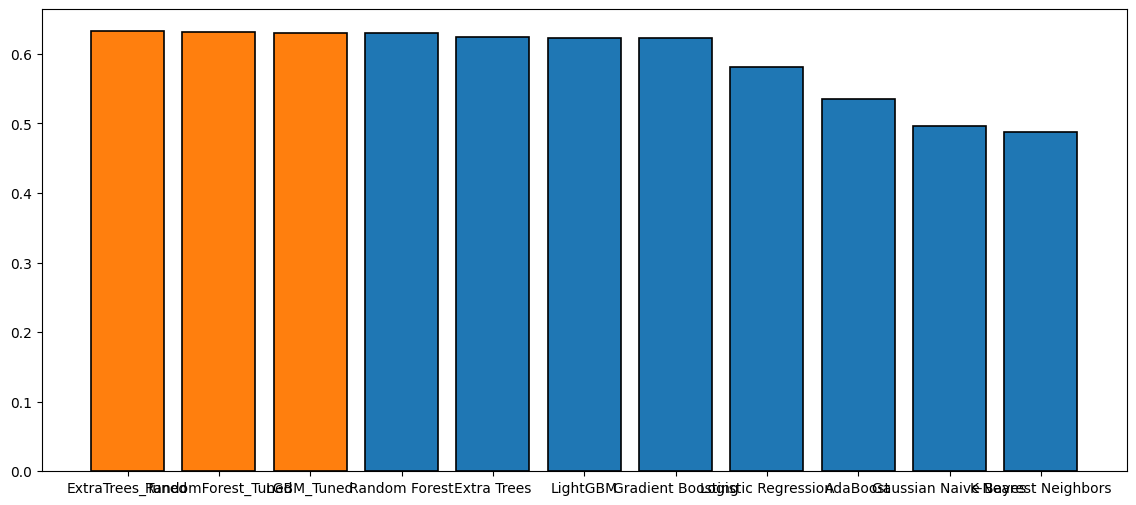

In [61]:
# Plotting the comparison
plt.figure(figsize=(14, 6))

# Map colors to model types
colors = results_df['Type'].map({
    'Base': '#1f77b4',    # Blue
    'Tuned': '#ff7f0e',   # Orange
    'Ensemble': '#2ca02c' # Green (if any ensemble models added)
})

bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='black', linewidth=1.2)

(0.5, 0.6826800264258974)

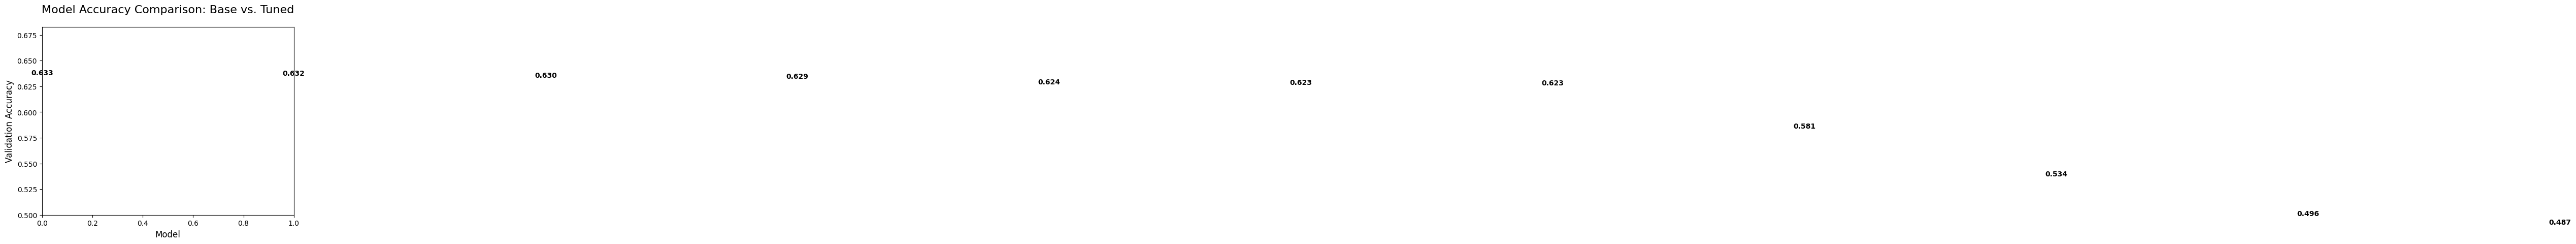

In [62]:
# Annotate bars with accuracy values
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{acc:.3f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Model Accuracy Comparison: Base vs. Tuned', fontsize=16, pad=20)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.ylim(0.5, results_df['Accuracy'].max() + 0.05)